Este primer apartado busca recabar las variables pricnipales para analizar como se desarolla el USD_MXN cen un cierto periodo de tiempo, con la finalidad de analizarla bajo la óptica de una serie de tiempo, para ello las variables que fungirán como descriptoras serán en un princippio la Tasa_Fed_10Y, el VIX y desde luego la USD_MXN.

Por ello, vale la pena exportar las librerías de trabajo en todo este notebook

In [ ]:
pip install yfinance pandas

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import het_arch


Para abrir el análisis, se importan las variables de interés mediante los denominados tickets dentro de YF en el intervalo del 2021-01-01 al 2026-07-17 

In [28]:
# definimos y extraemos los tickets dentro de yf
tickers = {
    "VIX": "^VIX",
    "Tasa_Fed_10Y": "^TNX"
}

df_raw = yf.download(list(tickers.values()), start="2021-01-01", end="2026-07-17")["Close"]

# Creamos una copia limpia y renombramos las columnas con nuestros nombres legibles
data_global = df_raw.copy()
data_global = data_global.rename(columns={ "^VIX": "VIX", "^TNX": "Tasa_Fed_10Y" })

data_global.head(10)


[*********************100%***********************]  2 of 2 completed


Ticker,Tasa_Fed_10Y,VIX
Date,,
2021-01-04,0.917,26.969999
2021-01-05,0.955,25.340000
2021-01-06,1.042,25.070000
2021-01-07,1.071,22.370001
2021-01-08,1.105,21.559999
2021-01-11,1.132,24.080000
2021-01-12,1.138,23.330000
2021-01-13,1.088,22.209999
2021-01-14,1.129,23.250000


In [29]:
# De manera análoga se implementa para el USD_MXN
ticker_peso = {"USD_MXN": "MXN=X"}

# Descargamos la serie histórica del tipo de cambio
df_peso_raw = yf.download(list(ticker_peso.values()), start="2021-01-01", end="2026-07-17")["Close"]

# Creamos una copia limpia y renombramos la columna
df_peso = pd.DataFrame(df_peso_raw.copy())
df_peso.columns = ticker_peso.keys()

df_peso.head(10)


[*********************100%***********************]  1 of 1 completed


,USD_MXN
Date,
2021-01-01,19.874500
2021-01-04,19.847500
2021-01-05,19.942450
2021-01-06,19.902201
2021-01-07,19.655769
2021-01-08,20.000099
2021-01-11,20.050489
2021-01-12,20.062401
2021-01-13,19.794430


In [30]:
# Unimos las dos tablas usando el índice 'Date' como eje de coordenadas temporal
df_main = pd.merge(df_peso, data_global, left_index=True, right_index=True, how="inner")

# Validamos que no existan valores nulos (NaN) provocados por la fusión
print("Conteo de Valores Nulos por Variable")
print(df_main.isna().sum())

print("\n Estructura de la Matriz Maestra")
df_main.head(10)


Conteo de Valores Nulos por Variable
USD_MXN         0
Tasa_Fed_10Y    1
VIX             0
dtype: int64

 Estructura de la Matriz Maestra


,USD_MXN,Tasa_Fed_10Y,VIX
Date,,,
2021-01-04,19.847500,0.917,26.969999
2021-01-05,19.942450,0.955,25.340000
2021-01-06,19.902201,1.042,25.070000
2021-01-07,19.655769,1.071,22.370001
2021-01-08,20.000099,1.105,21.559999
2021-01-11,20.050489,1.132,24.080000
2021-01-12,20.062401,1.138,23.330000
2021-01-13,19.794430,1.088,22.209999
2021-01-14,19.836349,1.129,23.250000


In [31]:
# se limpian los Nan y se rellena
df_main_clean = df_main.ffill()
#verificación:
df_main_clean.isna().sum()

USD_MXN         0
Tasa_Fed_10Y    0
VIX             0
dtype: int64

In [32]:
df_main_clean.shape

(1389, 3)

Una vez establecido el DataFrame principal de trabajo "df_main_clean", el data se encuentra en el momento exacto para verificar si es que si quiera si existe alguna correlación entre las variables, derivado de la naturaleza de los datos, no se tiene porque asumir alguna distribución es por ello que se recurre a la Correlación de Spearman ya que esta es independiente a la distribución y lo que mide es la monotocidad sin importar la escala lineal.

In [33]:
# Se calcula la correlación de Spearman
matriz_spearman = df_main_clean.corr(method='spearman')

print("MATRIZ DE CORRELACIÓN DE SPEARMAN")
matriz_spearman

MATRIZ DE CORRELACIÓN DE SPEARMAN


,USD_MXN,Tasa_Fed_10Y,VIX
USD_MXN,1.000000,-0.521793,0.547653
Tasa_Fed_10Y,-0.521793,1.000000,-0.379239
VIX,0.547653,-0.379239,1.000000


Estos datos muestran la macroeconomía estructural de largo plazo, se nota que a lo largo de los meses y años que si el VIX se mantiene elevada, el peso mexicano de forma estructural tiende a debilitarse y mantenerse alto. Por otra parte si la tasa baja, el capital fluye hacia los mercados emergentes de forma sostenida y el peso mexicano se fortalece

Validando la existencia de correlación entre variables, se puede encaminar hacia un análisis temporal clásico, el análisis de estacionariedad. Para ello se grafica las 3 series de tiempo con la finalidad de hacer un bosquejo visual, al mismo tiempo que se verifica que la varianza global de cada una de ellas se encuentre acotada y no sea explosiva.

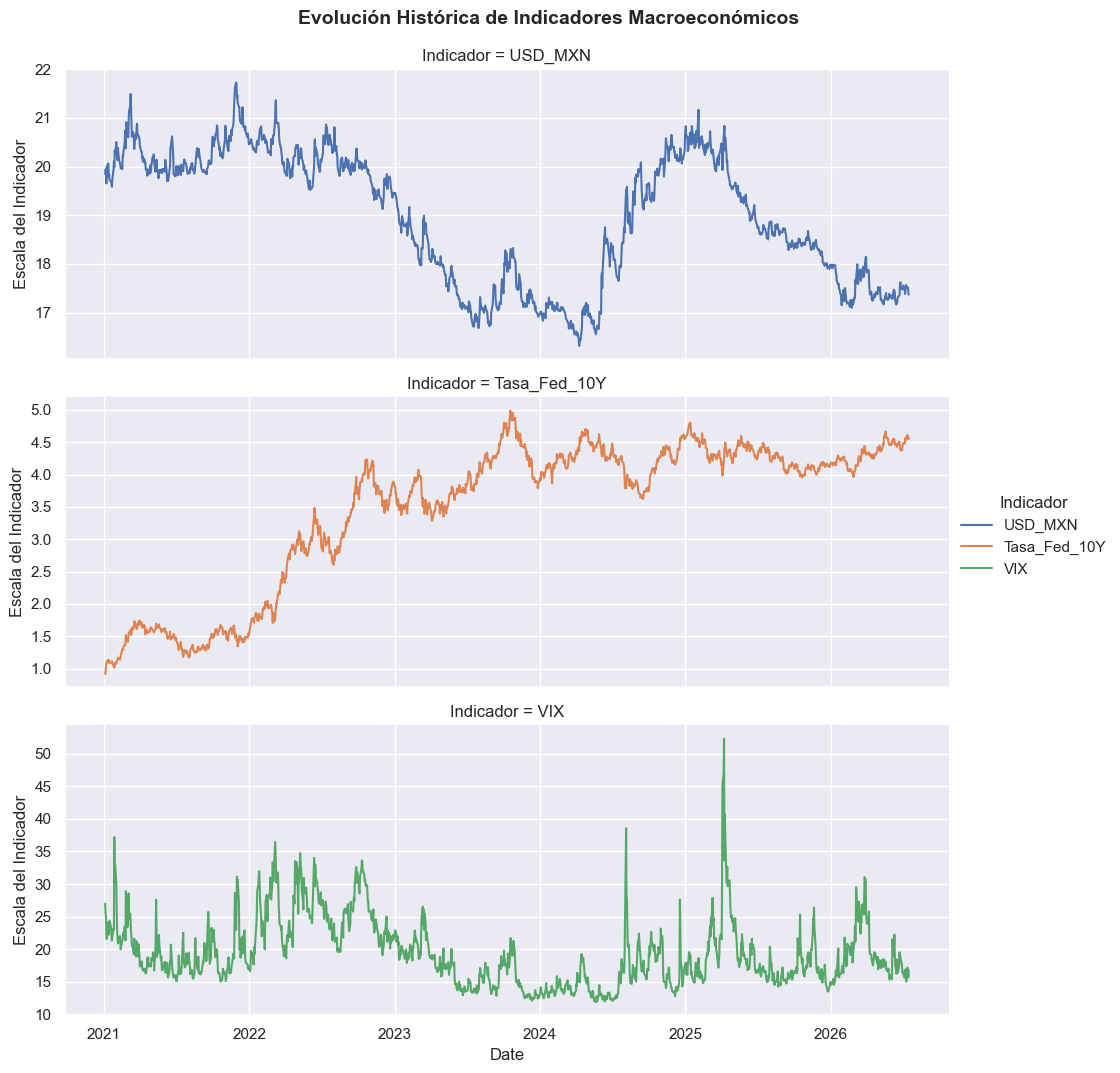

In [34]:
sns.set_theme(style="darkgrid")

# Se transforman los datos a formato largo
df_long = (df_main_clean[['USD_MXN', 'Tasa_Fed_10Y', 'VIX']]
    .reset_index()
    .melt(
        id_vars='Date', 
        var_name='Indicador', 
        value_name='Valor'
    )
)

# Se configura el gráfico
g = sns.relplot(
    data=df_long,
    x='Date',
    y='Valor',
    row='Indicador',     
    hue='Indicador',    
    kind='line',
    height=3.5,          
    aspect=2.8,          
    facet_kws=dict(sharey=False)
)

g.fig.suptitle('Evolución Histórica de Indicadores Macroeconómicos', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels('Date', 'Escala del Indicador', fontsize=12)

plt.show()


In [35]:
print("Auditoria de la varianza global de cada una mediante el BREUSCH-PAGAN")
print("-" * 52)

# Se calcula los días transcurridos directamente desde el índice Date
tiempo_num = (df_main_clean.index - df_main_clean.index.min()).days
X_tiempo = sm.add_constant(tiempo_num)

# Se indican las variables
variables = ['USD_MXN', 'Tasa_Fed_10Y', 'VIX']

# Se itera sobre cada columna
for var in variables:
    print(f"Variable Evaluada: {var}")
    
    # Se realiza una regresión contra el tiempo cronológico
    modelo_aux = sm.OLS(df_main_clean[var], X_tiempo).fit()
    residuos = modelo_aux.resid

    # Aplicación del test Breusch-Pagan directo al p-valor (posición 1)
    p_valor_global = het_breuschpagan(residuos, X_tiempo)[1]

    print(f" p-valor de Varianza Global: {p_valor_global:.4f}")

    # Resultados de la prueba veredicto
    if p_valor_global < 0.05:
        print(
            "Varianza global peligrosa; Requiere aplicar logaritmo natural.\n"
        )
    else:
        print(
            "Varianza global constante.\n"
        )
    print("-" * 52)

Auditoria de la varianza global de cada una mediante el BREUSCH-PAGAN
----------------------------------------------------
Variable Evaluada: USD_MXN
 p-valor de Varianza Global: 0.0000
Varianza global peligrosa; Requiere aplicar logaritmo natural.

----------------------------------------------------
Variable Evaluada: Tasa_Fed_10Y
 p-valor de Varianza Global: 0.0000
Varianza global peligrosa; Requiere aplicar logaritmo natural.

----------------------------------------------------
Variable Evaluada: VIX
 p-valor de Varianza Global: 0.2857
Varianza global constante.

----------------------------------------------------


Derivado del test de Breusch-Pagan, se procede a aplicar el logaritmo sobre las variables indicadas con la finalidad de brindar una estabilidad a la varianza global.

In [36]:
# Se clona el DataFrame para no alterar el original y se aplica log sobre las variables
df_main_log = df_main_clean.copy()

df_main_log["USD_MXN_log"] = np.log(df_main_log["USD_MXN"])
df_main_log["Tasa_Fed_10Y_log"] = np.log(df_main_log["Tasa_Fed_10Y"])
df_main_log["VIX"] = df_main_log["VIX"]
#Se mantiene el nombre de VIX sin log para que no se confunda sobre si se aplico a esa variable
df_main_log = df_main_log[["USD_MXN_log", "Tasa_Fed_10Y_log", "VIX"]]

df_main_log.head()

,USD_MXN_log,Tasa_Fed_10Y_log,VIX
Date,,,
2021-01-04,2.988078,-0.086648,26.969999
2021-01-05,2.992851,-0.046044,25.340000
2021-01-06,2.990830,0.041142,25.070000
2021-01-07,2.978371,0.068593,22.370001
2021-01-08,2.995737,0.099845,21.559999


Una vez estabilizada la varianza se da paso a las pruebas de ADF y KPSS con la finalidad de verificar que no se tenga raíces unitarias y se tenga una estacionariedad

In [37]:
# Se silencian advertencias temporales del test KPSS por memoria compleja si las hubiera
warnings.filterwarnings('ignore', category=InterpolationWarning) if 'InterpolationWarning' in locals() else warnings.filterwarnings('ignore', message=".*The test statistic is outside.*")

# Se declara los nombres de las columnas del data correspondiente
columnas_procesadas = ['USD_MXN_log', 'Tasa_Fed_10Y_log', 'VIX']

print("Auditoría de estabilidad en el promedio")
print("="*52)

for var in columnas_procesadas:
    print(f"Procesando variable: {var}")
    
    # 1. Test ADF
    p_val_adf = adfuller(df_main_log[var])[1]
    
    # 2. Test KPSS 
    p_val_kpss = kpss(df_main_log[var], regression='c')[1]
    
    print(f"  p-valor ADF:  {p_val_adf:.4f}")
    print(f"  p-valor KPSS: {p_val_kpss:.4f}")
    
    # 3. Aplicamos la matriz de confirmación cruzada
    if p_val_adf < 0.05 and p_val_kpss > 0.05:
        print("La serie es estacionaria.\n")
    elif p_val_adf >= 0.05 and p_val_kpss <= 0.05:
        print("La serie no es estacionaria.\n")
    else:
        print("Diagnóstico míxto.\n")

Auditoría de estabilidad en el promedio
Procesando variable: USD_MXN_log
  p-valor ADF:  0.4281
  p-valor KPSS: 0.0100
La serie no es estacionaria.

Procesando variable: Tasa_Fed_10Y_log
  p-valor ADF:  0.1192
  p-valor KPSS: 0.0100
La serie no es estacionaria.

Procesando variable: VIX
  p-valor ADF:  0.0000
  p-valor KPSS: 0.0100
Diagnóstico míxto.



Derivado de los test, se aplicará diferenciación en primer orden en las variables 'USD_MXN_log' y 'Tasa_Fed_10Y_log'. Mientras que al 'VIX' derivado de que la prueba ADF indica reversión a la media, diferenciar sobre esta variable provocaría borrar información útil en esta serie de tiempo y colapsaría a ruido blanco.

In [38]:
# Se crea la copia de df_main_log para no alterar los datos anteriores
df_stable = df_main_log.copy()

# Se aplica las diferencias correspondientes
df_stable['USD_MXN_stable'] = df_stable['USD_MXN_log'].diff()
df_stable['VIX_stable'] = df_stable['VIX']
df_stable['Tasa_Fed_10Y_stable'] = df_stable['Tasa_Fed_10Y_log'].diff()

# Se filtra por las columnas que se usarán
df_stable = df_stable[['USD_MXN_stable', 'Tasa_Fed_10Y_stable', 'VIX_stable']]

# Se limpian los valores nulos resultantes de la diferenciación
df_stable = df_stable.dropna()

df_stable.head()


,USD_MXN_stable,Tasa_Fed_10Y_stable,VIX_stable
Date,,,
2021-01-05,0.004773,0.040604,25.340000
2021-01-06,-0.002020,0.087186,25.070000
2021-01-07,-0.012459,0.027451,22.370001
2021-01-08,0.017366,0.031253,21.559999
2021-01-11,0.002516,0.024141,24.080000


De inmediato se tiene la libertad de visualisar las series de tiempo con la finalidad de observar los cambios de logarítmo y diferenciación de una forma visual

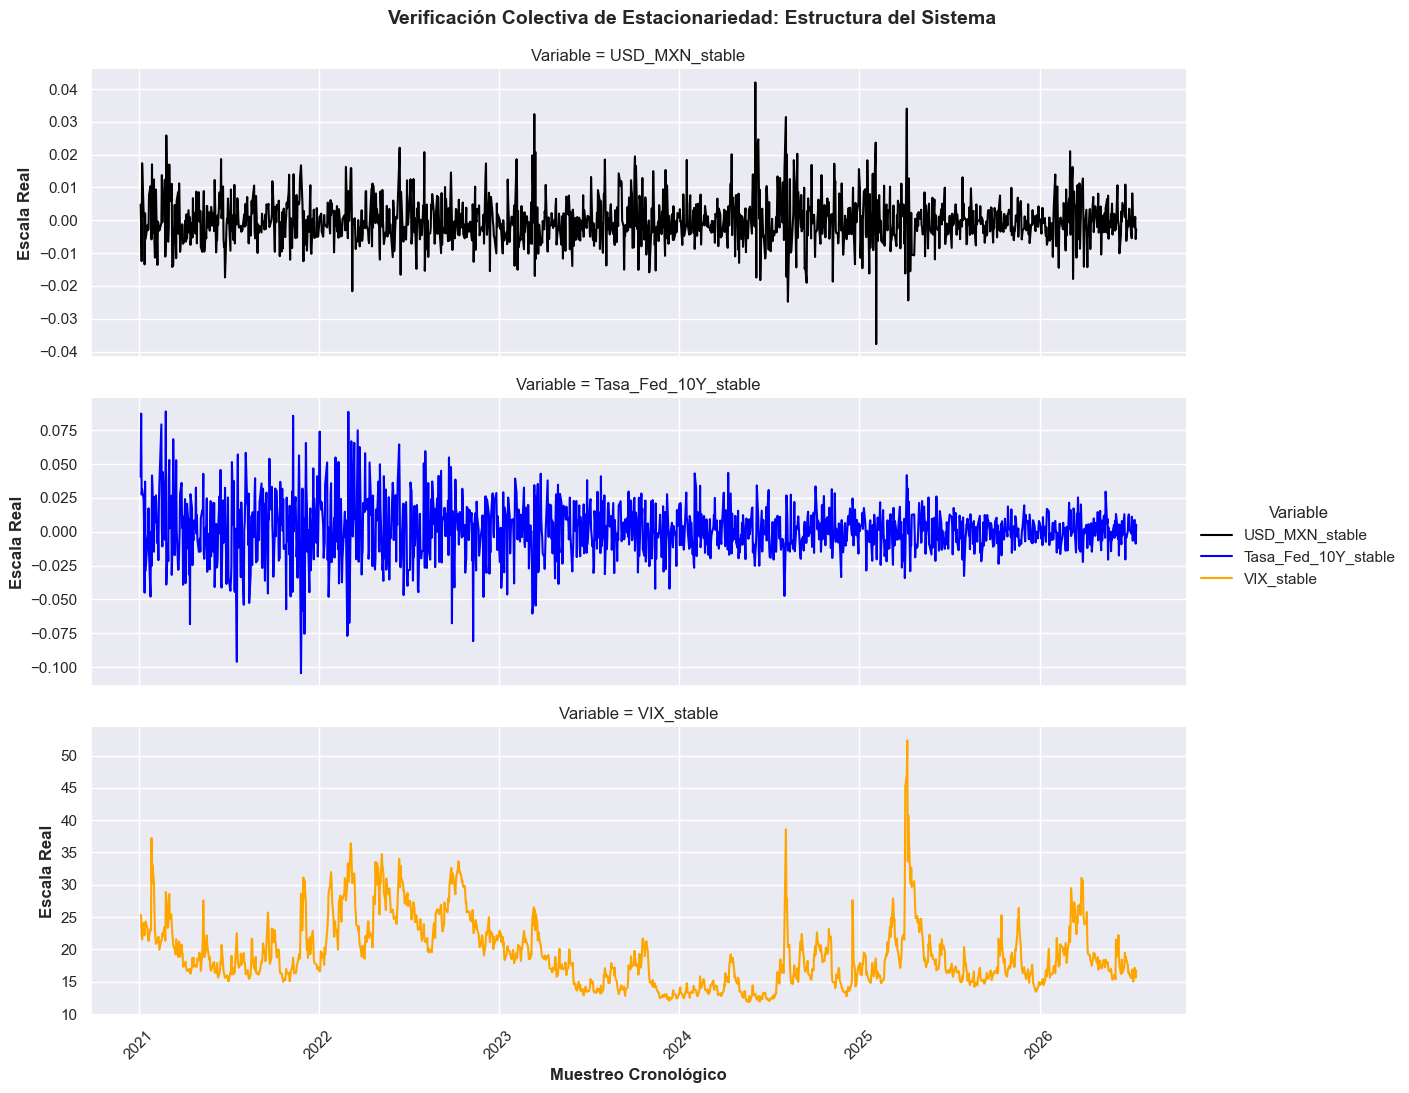

In [39]:
sns.set_theme(style="darkgrid")

# Se transforma a formato largo
df_long_st = (
    df_stable[['USD_MXN_stable', 'Tasa_Fed_10Y_stable', 'VIX_stable']]
    .reset_index()
    .melt(
        id_vars='Date', 
        var_name='Variable', 
        value_name='Valor'
    )
)

g = sns.relplot(
    data=df_long_st,
    x='Date',
    y='Valor',
    row='Variable',     
    hue='Variable',     
    palette=['black', 'blue', 'orange'],
    kind='line',
    linewidth=1.5,
    height=3.5,          
    aspect=3.5,          
    facet_kws=dict(sharey=False)
)

g.fig.suptitle('Verificación Colectiva de Estacionariedad: Estructura del Sistema', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels('Muestreo Cronológico', 'Escala Real', fontsize=12, fontweight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

plt.show()

Resultado del breve tratamiento anterior, resulta natural la corroboración de la estacionariedad sobre el DataFrame "df_stable" para asegurarse de que las series de tiempo se encuentren en condiciones adecuadas para un ánalisis mediante correlogramas.

In [40]:
# Silenciamos advertencias temporales del test KPSS por memoria compleja si las hubiera
warnings.filterwarnings('ignore', category=InterpolationWarning) if 'InterpolationWarning' in locals() else warnings.filterwarnings('ignore', message=".*The test statistic is outside.*")

columnas_procesadas = ['USD_MXN_stable', 'Tasa_Fed_10Y_stable', 'VIX_stable']

print("Auditoria de estabilidad en el promedio.")
print("="*52)

for var in columnas_procesadas:
    print(f"Procesando variable: {var}")
    
    # 1. Test ADF
    p_val_adf = adfuller(df_stable[var])[1]
    
    # 2. Test KPSS 
    p_val_kpss = kpss(df_stable[var], regression='c')[1]
    
    print(f"  p-valor ADF:  {p_val_adf:.4f}")
    print(f"  p-valor KPSS: {p_val_kpss:.4f}")
    
    # 3. Aplicamos la matriz de confirmación cruzada
    if p_val_adf < 0.05 and p_val_kpss > 0.05:
        print("La serie es estacionaria.\n")
    elif p_val_adf >= 0.05 and p_val_kpss <= 0.05:
        print("La serie no es estacionaria.\n")
    else:
        print("Diagnóstico míxto.\n")

Auditoria de estabilidad en el promedio.
Procesando variable: USD_MXN_stable
  p-valor ADF:  0.0000
  p-valor KPSS: 0.1000
La serie es estacionaria.

Procesando variable: Tasa_Fed_10Y_stable
  p-valor ADF:  0.0000
  p-valor KPSS: 0.0388
Diagnóstico míxto.

Procesando variable: VIX_stable
  p-valor ADF:  0.0000
  p-valor KPSS: 0.0100
Diagnóstico míxto.



Resultado de la corroboración de estacionariedad se logra concluir que la variable principal 'USD_MXN' se encuentra correctamente en estado estacionaria, sin embargo para la 'Tasa_Fed_10Y' aún no se encuentra de manera robusta en ese estado, en este caso específico, el diagnóstico se basará en lo que dictaminó el test ADF por, lo que derivado de que la 'Tasa_Fed_10Y' tiene reversión a la media con la finalidad de evitar una sobrediferenciación y forzar a que exista una correlación en el primer lag de -0.5 lo que indicaría ruido artifical, se decide no proseguir con una segunda diferenciación y proseguir con el análisis.

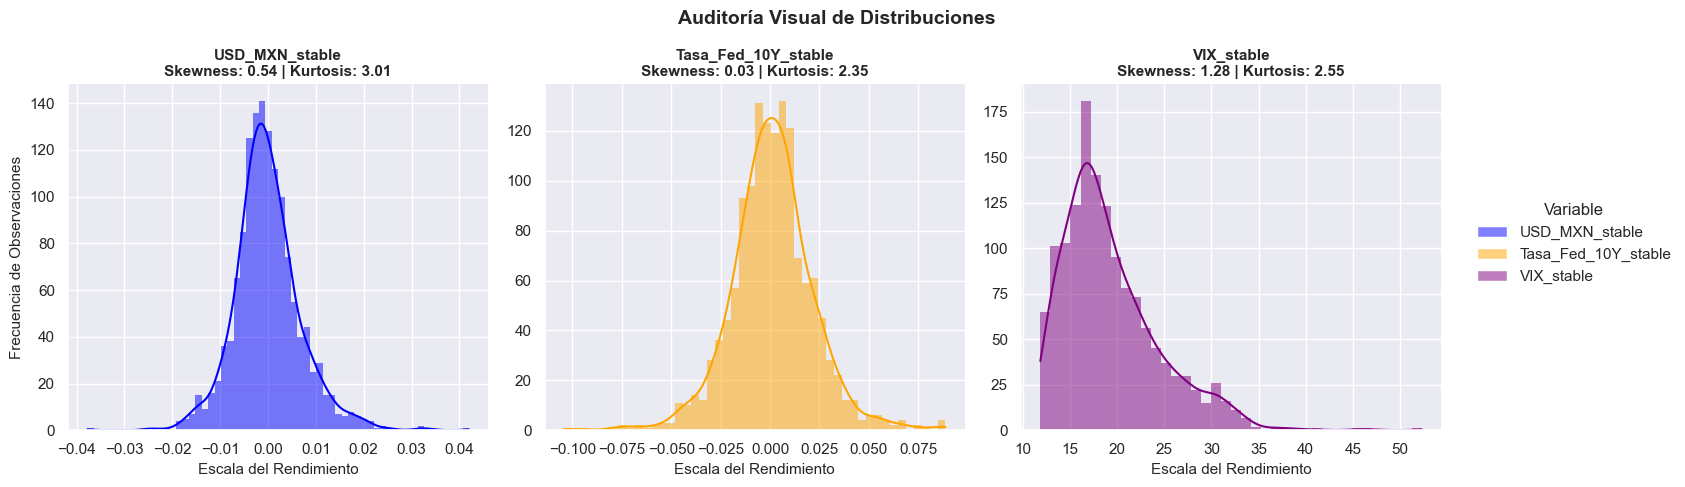

In [41]:
sns.set_theme(style="darkgrid")

# Se convierte el DataFrame a formato largo
df_long_dist = (
    df_stable[['USD_MXN_stable', 'Tasa_Fed_10Y_stable', 'VIX_stable']]
    .reset_index()
    .melt(
        id_vars=df_stable.index.name or 'Date', 
        var_name='Variable', 
        value_name='Valor'
    )
)

g = sns.displot(
    data=df_long_dist,
    x='Valor',
    col='Variable',      
    hue='Variable',
    palette=['blue', 'orange', 'purple'],
    kind='hist',
    kde=True,            
    height=4.5,          
    aspect=1.1,         
    common_bins=False, 
    facet_kws=dict(sharex=False, sharey=False)
)


for ax, title_name in zip(g.axes.flat, g.col_names):
    # Cálculo de métricas
    skew_val = df_stable[title_name].skew()
    kurt_val = df_stable[title_name].kurt()
    
    ax.set_title(
        f"{title_name}\nSkewness: {skew_val:.2f} | Kurtosis: {kurt_val:.2f}", 
        fontsize=11, 
        fontweight='bold'
    )

g.fig.suptitle('Auditoría Visual de Distribuciones', y=1.08, fontsize=14, fontweight='bold')
g.set_axis_labels('Escala del Rendimiento', 'Frecuencia de Observaciones', fontsize=11)

plt.show()


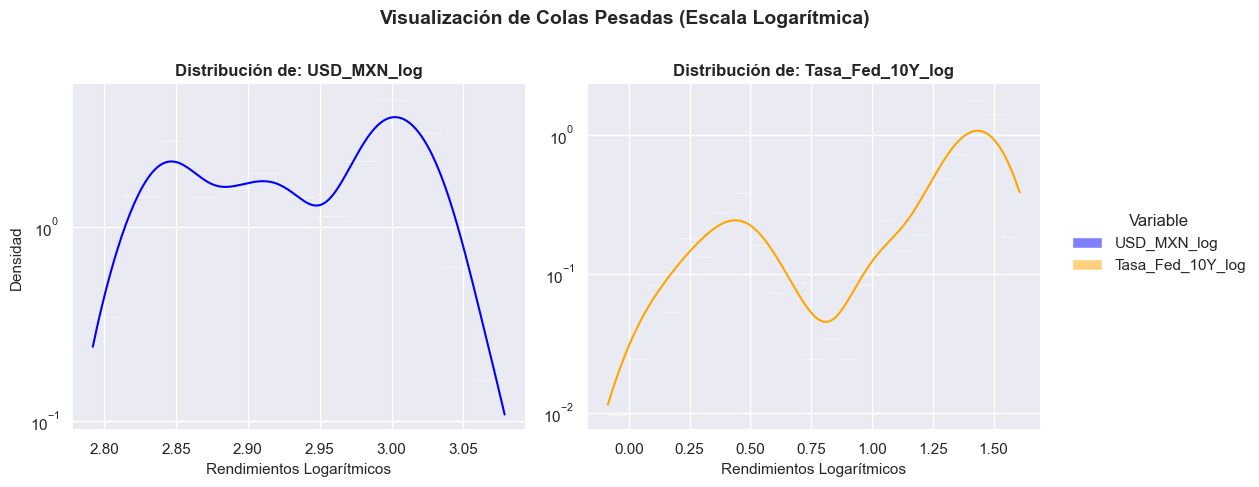

In [42]:
sns.set_theme(style="darkgrid")

# Data en formato largo
df_long_colas = (
    df_main_log[['USD_MXN_log', 'Tasa_Fed_10Y_log']]
    .reset_index()
    .melt(
        id_vars=df_main_log.index.name or 'Date', 
        var_name='Variable', 
        value_name='Rendimientos'
    )
)

g = sns.displot(
    data=df_long_colas,
    x='Rendimientos',
    col='Variable',     
    hue='Variable',      
    palette=['blue', 'orange'], 
    kind='hist',
    kde=True,           
    stat='density',     
    log_scale=(False, True), 
    common_bins=False, 
    height=4.5,          
    aspect=1.2,          
    facet_kws=dict(sharex=False, sharey=False)
)


g.fig.suptitle('Visualización de Colas Pesadas (Escala Logarítmica)', y=1.08, fontsize=14, fontweight='bold')
g.set_axis_labels('Rendimientos Logarítmicos', 'Densidad', fontsize=11)

for ax, title_name in zip(g.axes.flat, g.col_names):
    ax.set_title(f"Distribución de: {title_name}", fontsize=12, fontweight='bold')

plt.show()


Diagnóstico de asimetría y curtosis:

Tras configurar las variables financieras a la par de que se aisló el VIX en diferencias directas y sin alteración logarítmica (derivado del test de varianza global y para conservar su estructura en los correlogramas futuros). Con la finalidad de preservar en la escala nativa sus picos de volatilidad, se consolidó "df_stable".

De la evaluación de los momentos muestrales, se arrojan las firmas estadísticas del ecosistema de riesgo planteado:

* El canal cambiario USD_MXN_stable: 

La asimetría de 0.54 demuestra empiricamente que los rendimientos del peso mexicano exhibe un sesgo hacia la derecha es decir los movimientos de la devaluación ocurren con mayor violencia y magnitud que los movimientos de apreciación exponiendo la vulnerabilidad estructural de la divisa ante choques, por otra parte la curtosis representa una cifra de esceso y exhibe la **existencia de colas pesadas** superando drásticamente el umbral de una distribución normal, se confirma que los eventos extremos de mercado tienen una probabilidad de ocurrencia sustancialmente mayor en la realidad de los mercados en los que habita el peso mexicano ie en mercados emergentes. 

* Atractividad de la Tasa_Fed_stable:

Para este caso se tiene una simetría que indica que su morfología se encuentra balanceada en su dirección, donde, los choques al costo del dinero se distribuyen de forma equitativa hacia el azar sin encambio el exceso de curtósis  exhibe que la asimetría de las desiciones de política de la Fed y el rebalanceo de los bonos, inyectan impulsos hacia el canal de transmisión macroeconómica, actuando como un detonador de alta densidad sobre el peso mexicano.

* Estabilidad del VIX:

La asimetría compueba que el miedo en Wall Street opera bajo una ley de velocidad asimétrica; sube mediante saltos masivos y se dispara de forma paulatina impactando al peso de forma rezagada, mientras que la curtosis en exceso confirma la naturaleza explosiva de la aversión al riesgo.


# comenzaremos con el análisis de la ACF y la PACF. 

Esto con la finalidas de mostrar una orientación sobre la naturaleza de los procesos, si optamos por un AR o MA, es por ello que se coteja mediante la ACF y la PACF; el impacto acumulado directo e impacto que el pasado ejerce sobre el presente de las series de tiempo.

Análisis de identidad temporal de: USD_MXN_stable


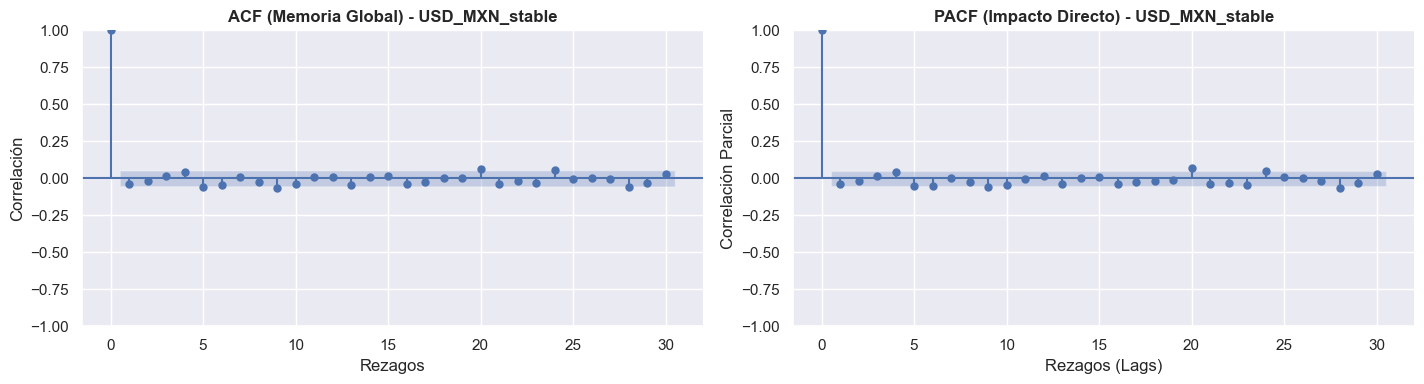

Análisis de identidad temporal de: Tasa_Fed_10Y_stable


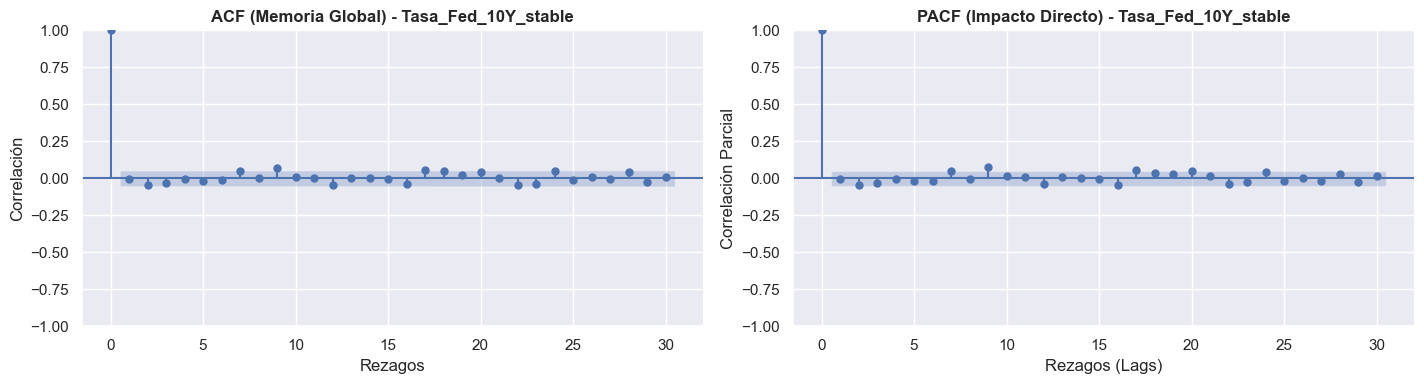

Análisis de identidad temporal de: VIX_stable


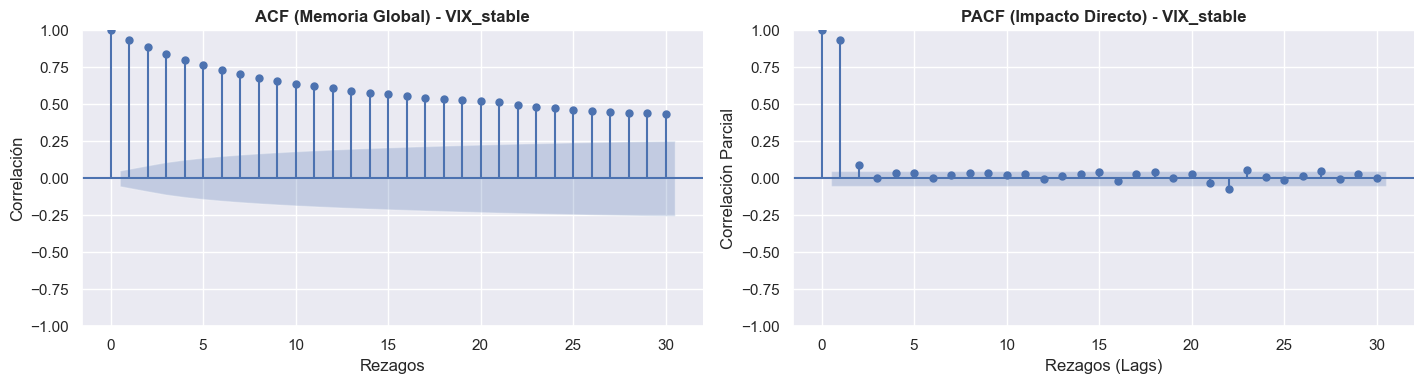

In [43]:
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# Se definen las variables de interés
variables_analisis = ['USD_MXN_stable', 'Tasa_Fed_10Y_stable', 'VIX_stable']


# Se itera sobre cada variable para su renderizado
for var in variables_analisis:
    print(f"Análisis de identidad temporal de: {var}")
    print("=" * 50)
    
    # Se crea un DataFrame temporal de dos columnas idénticas de la variable
    df_temp = df_stable[[var]].copy()
    df_temp['Tipo_Analisis'] = 'ACF (Memoria Global)'
    df_temp_2 = df_stable[[var]].copy()
    df_temp_2['Tipo_Analisis'] = 'PACF (Impacto Directo)'
    
    df_grid = pd.concat([df_temp, df_temp_2]).reset_index()
    
    g = sns.FacetGrid(
        data=df_grid,
        col='Tipo_Analisis',
        sharex=False,
        sharey=False,
        height=4,
        aspect=1.8
    )
    
    # Panel izquierdo: Grafica de la ACF
    plot_acf(df_stable[var], lags=30, ax=g.axes[0][0])
    g.axes[0][0].set_title(f"ACF (Memoria Global) - {var}", fontsize=12, fontweight='bold')
    g.axes[0][0].set_xlabel("Rezagos")
    g.axes[0][0].set_ylabel("Correlación")
    
    # Panel derecho: Grafica de la PACF
    plot_pacf(df_stable[var], lags=30, method='ols', ax=g.axes[0][1])
    g.axes[0][1].set_title(f"PACF (Impacto Directo) - {var}", fontsize=12, fontweight='bold')
    g.axes[0][1].set_xlabel("Rezagos (Lags)")
    g.axes[0][1].set_ylabel("Correlación Parcial")
    
    g.fig.subplots_adjust(top=0.8)
    plt.tight_layout()
    plt.show()

Análisis de correlogramas ACF y PACF:


Tras estabilizar la varianza, remover la raíz unitaria y calibrar el filtrado de las series de tiempo, se procedió a auditar la estructura de memoria lineal residual mediante las funciones de Autocorrelación Global (ACF) y Autocorrelación Parcial (PACF) hasta el rezago 30. Los nuevos patrones morfológicos revelan el comportamiento dinámico puro del sistema:

* El Canal Cambiario USD_MXN_stable:

Tanto en la función ACF como en la PACF, la inmensa mayoría de los coeficientes de correlación diaria se confinan y mueren de forma generalizada dentro de las bandas de confianza estadística. Por lo que el peso mexicano se comporta en su media lineal como un Ruido Blanco. Esto aporta la validación empírica de la hipótesis de mercados eficientes: la dirección del rendimiento diario del tipo de cambio es linealmente impredecible utilizando su propio pasado inmediato, confirmando que la media condicional opera como un proceso linealmente libre de memoria.

* Atractividad de la Tasa_Fed_stable:

De manera idéntica al canal cambiario, el correograma de la tasa soberana de EE. UU. muestra que la totalidad de las barras de la ACF y la PACF caen de forma unánime e inmediata en la zona de inactividad informativa dentro de los límites de control, sin exhibir cortes abruptos ni decaimientos geométricos fuera del umbral, se muestra que al aplicar la primera diferencia logarítmica, la tasa de la Fed se reduce a un proceso de ruido blanco. Esto demuestra que los choques al costo del dinero se disipan de forma instantánea en el espacio lineal de la media condicional. El mercado de bonos asimila la información económica de forma eficiente y sin arrastrar inercias o retrocesos elásticos artificiales, consolidándose como un vector de impulsos limpios de tendencia para el sistema cruzado.

* El VIX:

La función PACF exhibe un truncamiento o corte abrupto exactamente en el Lag 2, mientras que de forma matemática síncrona la función ACF muestra un decaimiento geométrico amortiguado. Este patrón morfológico confirma que el cambio diario en la aversión al riesgo global se rige rígidamente bajo un proceso AR(2). Esto demuestra que el miedo en Wall Street posee una inercia: cuando ocurre un estallido de pánico, la onda de choque informativa no se disipa en 24 horas; genera un impulso que se propaga y durante 48 horas hábiles completas (2 días financieros) antes de enfriarse.



En base a lo anterior, resulta natural proceder con el modelado tipo ARIMA en base a la información extraida en los correlogramas.

In [44]:
# Se alimenta a los modelos con las variables de 'df_main_log'

# USD_MXN: Aplicamos ARIMA(0,1,0)
modelo_usd = ARIMA(df_main_log['USD_MXN_log'], order=(0, 1, 0)).fit()
residuos_usd = modelo_usd.resid

# Tasa Fed 10Y: Aplicamos ARIMA(0,1,0)
modelo_tasa = ARIMA(df_main_log['Tasa_Fed_10Y_log'], order=(0, 1, 0)).fit()
residuos_tasa = modelo_tasa.resid

# VIX
modelo_vix = ARIMA(df_main_log['VIX'], order=(2, 0, 0)).fit()
residuos_vix = modelo_vix.resid

# Se consolida las 3 series de tiempo de puros errores en un nuevo DataFrame de auditoría
df_residuos_arima = pd.DataFrame({
    'residuos_usd': residuos_usd,
    'residuos_tasa': residuos_tasa,
    'residuos_vix': residuos_vix
}, index=df_main_clean.index)


print("\nData de residuos ARIMA")
df_residuos_arima.head(10)


Data de residuos ARIMA


,residuos_usd,residuos_tasa,residuos_vix
Date,,,
2021-01-04,2.988078,-0.086648,7.596236
2021-01-05,0.004773,0.040604,-1.152322
2021-01-06,-0.002020,0.087186,-0.070264
2021-01-07,-0.012459,0.027451,-2.396764
2021-01-08,0.017366,0.031253,-0.874306
2021-01-11,0.002516,0.024141,2.574580
2021-01-12,0.000594,0.005286,-0.259464
2021-01-13,-0.013447,-0.044931,-0.958606
2021-01-14,0.002116,0.036991,1.104755


In [45]:
# Se elimina la primer fila por control
df_residuos_puros = df_residuos_arima.iloc[1:].copy()

# Verificación de dimensiones del nuevo DataFrame
print("Dimensión de los resiudos depurados:")
print(df_residuos_puros.shape)


df_residuos_puros.head()


Dimensión de los resiudos depurados:
(1388, 3)


,residuos_usd,residuos_tasa,residuos_vix
Date,,,
2021-01-05,0.004773,0.040604,-1.152322
2021-01-06,-0.002020,0.087186,-0.070264
2021-01-07,-0.012459,0.027451,-2.396764
2021-01-08,0.017366,0.031253,-0.874306
2021-01-11,0.002516,0.024141,2.574580


Con la finalidad de orientar el análisis hacia un modelado GARCH, se construye un nuevo DataFrame con los residuos elevados al cuadrado, lo anterior con la intención de visualizar la varianza condicional de las series de tiempo mediante correlogramas

In [46]:
# Creación del nuevo DataFrame
df_residuos_cuadrados = df_residuos_puros ** 2

# Renombre para analizar volatilidad
df_residuos_cuadrados.columns = ['volatilidad_usd', 'volatilidad_tasa', 'volatilidad_vix']

# Verificación de dimensiones
print("Dimensiones del DataFrame de resiudos cuadrados:")
print(df_residuos_cuadrados.shape)

df_residuos_cuadrados.head(10)


Dimensiones del DataFrame de resiudos cuadrados:
(1388, 3)


,volatilidad_usd,volatilidad_tasa,volatilidad_vix
Date,,,
2021-01-05,2.277730e-05,0.001649,1.327845
2021-01-06,4.081574e-06,0.007601,0.004937
2021-01-07,1.552368e-04,0.000754,5.744475
2021-01-08,3.015895e-04,0.000977,0.764411
2021-01-11,6.331922e-06,0.000583,6.628461
2021-01-12,3.527095e-07,0.000028,0.067322
2021-01-13,1.808187e-04,0.002019,0.918926
2021-01-14,4.475397e-06,0.001368,1.220484
2021-01-15,3.263663e-05,0.000827,1.969583


Análisis de: volatilidad_usd
--------------------------------------------------


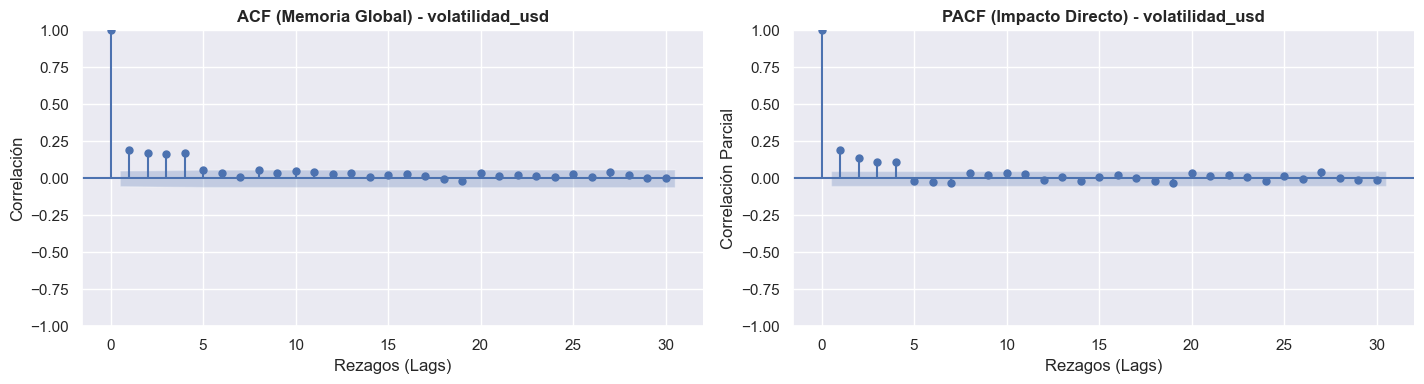

Análisis de: volatilidad_tasa
--------------------------------------------------


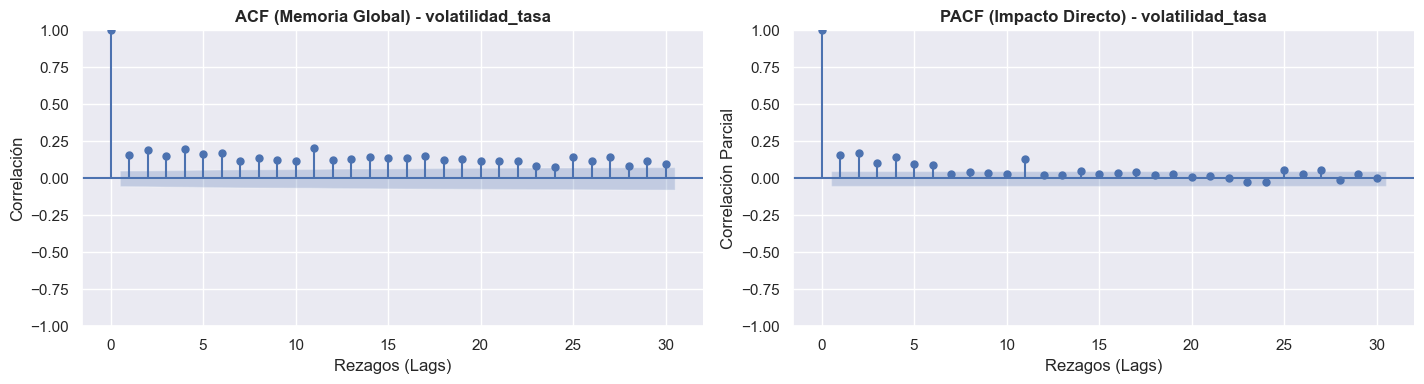

Análisis de: volatilidad_vix
--------------------------------------------------


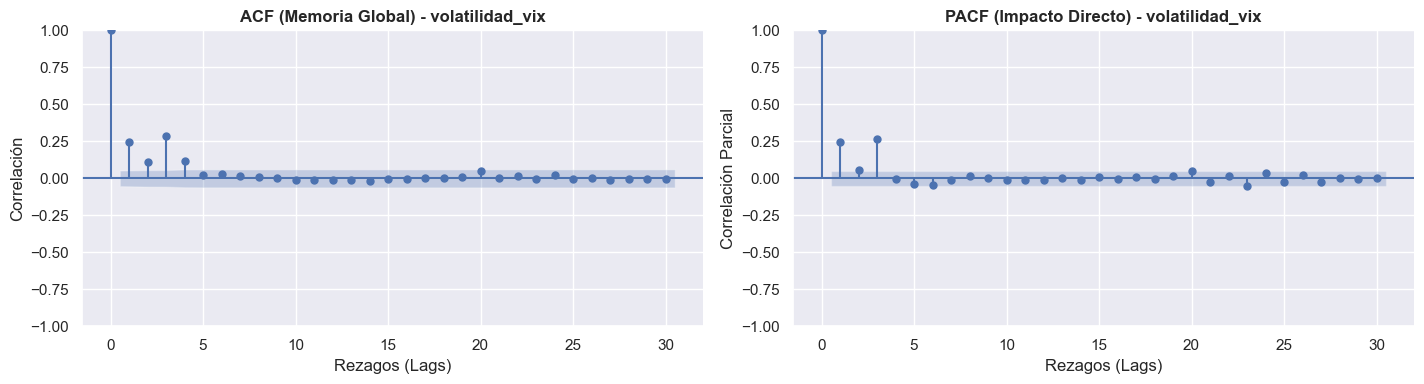

In [47]:
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

# Variables de volatilidad
variables_analisis = ['volatilidad_usd', 'volatilidad_tasa', 'volatilidad_vix']



for var in variables_analisis:
    print(f"Análisis de: {var}")
    print("-" * 50)
    
    df_temp_acf = pd.DataFrame({'Tipo_Analisis': ['ACF (Memoria Global)'] * len(df_residuos_cuadrados)})
    df_temp_pacf = pd.DataFrame({'Tipo_Analisis': ['PACF (Impacto Directo)'] * len(df_residuos_cuadrados)})
    df_grid = pd.concat([df_temp_acf, df_temp_pacf]).reset_index(drop=True)
    
    g = sns.FacetGrid(
        data=df_grid,
        col='Tipo_Analisis',
        sharex=False,
        sharey=False,
        height=4,
        aspect=1.8
    )
    
    # Gráficos de la ACF
    plot_acf(df_residuos_cuadrados[var], lags=30, ax=g.axes[0, 0])
    g.axes[0, 0].set_title(f"ACF (Memoria Global) - {var}", fontsize=12, fontweight='bold')
    g.axes[0, 0].set_xlabel("Rezagos (Lags)")
    g.axes[0, 0].set_ylabel("Correlación")
    
    # Gráficos de la PACF
    plot_pacf(df_residuos_cuadrados[var], lags=30, method='ols', ax=g.axes[0, 1])
    g.axes[0, 1].set_title(f"PACF (Impacto Directo) - {var}", fontsize=12, fontweight='bold')
    g.axes[0, 1].set_xlabel("Rezagos (Lags)")
    g.axes[0, 1].set_ylabel("Correlación Parcial")
    
    g.fig.subplots_adjust(top=0.85)
    plt.tight_layout()
    plt.show()

Diagnóstico de la varianza condicional

* volatilidad_usd:
  
A diferencia de la serie normal que operaba como un ruido blanco sin memoria, los residuos al cuadrado del Peso Mexicano exhiben una estructura de decaimiento geométrico en el ACF y un truncamiento simultáneo en el lag 4 para ambas funciones.
Esto representa la prueba de la Aglomeración de Volatilidad ya que demuestra empíricamente que los choques financieros extremos no ocurren de forma aislada o independiente en el tiempo; la turbulencia motiva turbulencia. El corte abrupto e idéntico invalida la necesidad de calibrar un modelo ARCH de orden alto el cual sufriría de sobreajuste y justifica de forma contundente la especificación de un modelo GARCH(1,1). Al incluir la propia varianza pasada como regresor, la estructura autorregresiva condicional absorbe esta memoria de corto plazo de forma altamente eficiente.

* volatilidad_tasa:

El ACF de las tasas de interés de EE. UU. muestra barras significativas que se extienden de manera indefinida fuera del intervalo de confianza estadística (hasta el lag 30 y posteriores), mientras que el PACF se confina hacia el lag 11 exhibiendo discontinuidades intermedias.
Este comportamiento modela el fenómeno de Memoria Larga de la Volatilidad indicando que el costo global del dinero reacciona ante cambios estructurales profundos en la macroeconomía mundial. Un choque en la tasa de la Fed altera de forma persistente el riesgo sistémico durante meses enteros. Intentar modelar esto con un ARCH(11) saturaría de parámetros el sistema; por ende, se documenta la existencia de una varianza integrada de largo plazo que interactuará de forma no lineal con el canal cambiario.
Esta geometría combinada con la observada en la PACF representa la firma empírica inconfundible de Efectos ARCH.Por lo que demuestra que si bien el VIX es eficiente en su dirección diaria por el ruido balnco residual, la magnitud de sus variaciones se agrupa de forma estricta en Racimos de Incertidumbre. Por lo que un estallido de volatilidad implícita en Nueva York el día de hoy altera de forma determinista la varianza de los próximos 3 a 4 días financieros, destruyendo el supuesto clásico de varianza constante y justificando por qué el portafolio requerirá modelar estas variables mediante motores de varianza dinámica.

* volatilidad_vix:

El análisis de los correlogramas revela picos estadísticamente significativos, de forma notable. Este comportamiento constituye una prueba intuitiva contundente de la existencia de efectos ARCH. Se demuestra así que la volatilidad del VIX se agrupa en clústeres y que su varianza condicional depende de sus propios choques pasados, lo que invalida el supuesto de homocedasticidad y justifica formalmente la extensión del análisis hacia un modelo de la familia GARCH para capturar la estructura de la varianza.

A estas alturas del análisis, resulta conveniente realizar el test de causalidad de Granger con la finalidad de motivar una implicación temporal entre las variables aledañas y la variable principal USD_MXN

In [48]:
# Test hasta el lag=5 para auditar toda la semana financiera
print("Test de causalidad de granger: VIX -> USD_MXN")
resultados_vix = grangercausalitytests(df_stable[['USD_MXN_stable', 'VIX_stable']], maxlag=5, verbose=True)

print("Test de causalidad de grange: rTASA -> USD_MXN")
resultados_tasa = grangercausalitytests(df_stable[['USD_MXN_stable', 'Tasa_Fed_10Y_stable']], maxlag=5, verbose=True)

Test de causalidad de granger: VIX -> USD_MXN

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.0225  , p=0.0252  , df_denom=1384, df_num=1
ssr based chi2 test:   chi2=5.0334  , p=0.0249  , df=1
likelihood ratio test: chi2=5.0243  , p=0.0250  , df=1
parameter F test:         F=5.0225  , p=0.0252  , df_denom=1384, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=104.4835, p=0.0000  , df_denom=1381, df_num=2
ssr based chi2 test:   chi2=209.7235, p=0.0000  , df=2
likelihood ratio test: chi2=195.2948, p=0.0000  , df=2
parameter F test:         F=104.4835, p=0.0000  , df_denom=1381, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=74.0701 , p=0.0000  , df_denom=1378, df_num=3
ssr based chi2 test:   chi2=223.3390, p=0.0000  , df=3
likelihood ratio test: chi2=207.0600, p=0.0000  , df=3
parameter F test:         F=74.0701 , p=0.0000  , df_denom=1378, df_num=3

Granger Causality
number of lags (no zero

Para determinar la dirección y la latencia de la transmisión de información macroeconómica hacia el canal cambiario mexicano, se ejecutó el Test de Causalidad de Granger sobre el DataFrame estrictamente estacionario (df_estacionario). Al estar las series libres de raíces unitarias, el contraste es inmune al sesgo de la regresión espuria.

Se evaluó una ventana secuencial de 1 a 5 días hábiles (una semana financiera completa) para capturar las asimetrías informativas del sistema cruzado.

1. VIX -> USD_MXN:

Primer rezago 1; Al reportar un p-valor de 0.0249 en la prueba de chi2, se rechaza formalmente la hipótesis nula de no-causalidad a un nivel de confianza estadística del 95%. Esto comprueba que los choques crudos en el Índice del Miedo de Wall Street tienen un impacto inmediato y transmiten información lineal predictiva hacia el Peso Mexicano en las primeras 24 horas. A partir del Rezago 2 y de forma unánime hasta el Rezago 5, el p-valor colapsa con estadísticos F monumentales. Esto demuestra que la onda de choque de la aversión al riesgo global no se disipa, sino que se amplifica masivamente a las 48 horas de ocurrir el evento. Esta asimetría temporal coincide perfectamente con la estructura interna AR(2) que se descubrió en los correlogramas del VIX; el miedo arrastra una inercia de 2 días en Wall Street, explicando de forma matemática por qué la fuerza de causalidad sobre el canal cambiario mexicano alcanza su clímax y domina el sistema tras un desfase friccional de 2 días hábiles. 

2. Tasa_Fed_10Y -> USD_MXN:

Todos los rezagos de la tasa de EE. UU. reportan p-valores colapsados, a diferencia del VIX, se oberva que los movimientos en el diferencial de tasas de interés actúan como una fuerza macroeconómica instantánea y persistente. Los flujos de capital globales y los algoritmos de arbitraje reaccionan en milisegundos ante cambios en el rendimiento libre de riesgo americano, moldeando y causando la trayectoria lineal del Peso Mexicano desde el primer día y manteniendo la presión informativa durante el resto de la semana financiera

Dadas la condiciones y amplio análisis de las variables financieras, finalmente se puede ejecutar el test ARCH para dar pie a la última corroboración sobre efectos de no estacionariedad en la varianza condicional.

In [49]:
# Ejecución de test ARCH para la variable principal de análisis del peso mexicano
lm_stat, p_value, f_stat, f_p_value = het_arch(df_residuos_puros['residuos_usd'], maxlag=5)

print("Test ARCH")
print(f"Estadístico (LM): {lm_stat:.4f}")
print(f"p-valor del Test de ARCH:          {p_value:.6f}")
print("="*52)

# Regla de decisión
if p_value < 0.05:
    print("VEREDICTO: p-valor < 0.05. Se RECHAZA la hipótesis nula de varianza constante.")
    print("Existe evidencia estadística de Efectos ARCH.")
    print("Requiere modelo GARCH.")
else:
    print("VEREDICTO: No se rechaza la hipótesis nula. La varianza es constante.")


Test ARCH
Estadístico (LM): 110.2097
p-valor del Test de ARCH:          0.000000
VEREDICTO: p-valor < 0.05. Se RECHAZA la hipótesis nula de varianza constante.
Existe evidencia estadística de Efectos ARCH.
Requiere modelo GARCH.


El p-valor resultante es estrictamente menor al nivel de significancia convencional, lo que nos obliga a rechazar contundentemente la hipótesis nula de varianza constante con un nivel de confianza bastante robusto. El estadístico LM de 110.21 demuestra que los choques de información pasados ejercen una fuerza de atracción masiva sobre la incertidumbre actual, confirmando formalmente que el par USD/MXN se rige bajo el fenómeno de Aglomeración de Volatilidad.Este hallazgo da pie al modelado GARCH en el siguiente notebook.

In [50]:
# exportando los DataFrames adecuados para trabajar dentro del notebook 2:

#el de los residuos para poder alimentar el modelo GARCH
df_residuos_puros.to_csv('residuos_puros_arima.csv', index=True)
#el de los logaritmos para VAR
df_main_log.to_csv('data_main_log.csv', index=True)
# para el notebook 3
df_stable.to_csv('data_stable.csv', index=True)